In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00


## qkd


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np

n = 8
backend = AerSimulator()

key = []

for i in range(n):
    qc = QuantumCircuit(1,1)

    # Alice randomly prepares |0> or |1>
    bit = np.random.randint(2)
    if bit == 1:
        qc.x(0)

    # Bob measures directly
    qc.measure(0,0)

    qc = transpile(qc, backend)
    result = backend.run(qc, shots=1).result().get_counts()
    measured = int(list(result.keys())[0])

    key.append(measured)

print("Generated Key:", key)

Generated Key: [1, 0, 1, 0, 0, 0, 0, 1]


## bb84


In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np

def bb84(n_bits=20):
    backend = AerSimulator()

    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)
    bob_bases = np.random.randint(2, size=n_bits)

    sifted_key = []

    for i in range(n_bits):
        qc = QuantumCircuit(1, 1)

        # Alice encoding
        if alice_bits[i] == 1:
            qc.x(0)
        if alice_bases[i] == 1:
            qc.h(0)

        # Bob measurement
        if bob_bases[i] == 1:
            qc.h(0)

        qc.measure(0, 0)

        qc = transpile(qc, backend)
        result = backend.run(qc, shots=1).result().get_counts()
        measured = int(list(result.keys())[0])

        # Keep only matching bases
        if alice_bases[i] == bob_bases[i]:
            sifted_key.append(measured)

    return sifted_key

bb84_key = bb84(30)
print("BB84 Key:", bb84_key)

BB84 Key: [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1]


## grover


Grover Result: {'11': 1024}


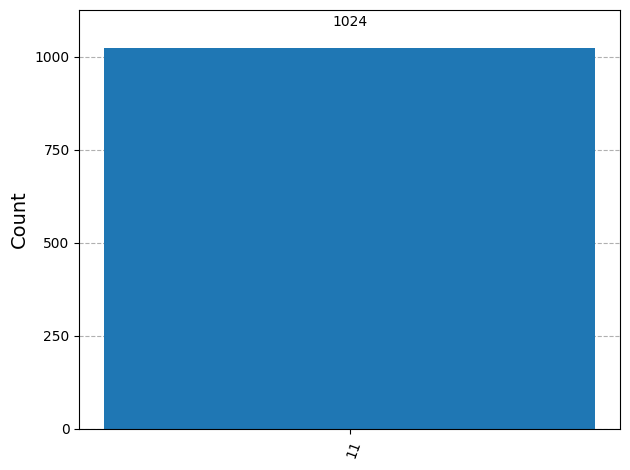

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

backend = AerSimulator()

qc = QuantumCircuit(2, 2)

# Step 1: Superposition
qc.h([0, 1])

# Step 2: Oracle
qc.cz(0,1)

# Step 3: Diffusion operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0,1)
qc.x([0, 1])
qc.h([0, 1])

qc.measure([0, 1], [0, 1])

qc = transpile(qc, backend)
counts = backend.run(qc, shots=1024).result().get_counts()

print("Grover Result:", counts)
plot_histogram(counts)